In [36]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('fivethirtyeight')

In [37]:
end=datetime.now()
start=datetime(end.year-20,end.month,end.day)
stock='DOGE-USD'
stock_data=yf.download(stock,start=start,end=end)

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_25004\1325415555.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data=yf.download(stock,start=start,end=end)
[*********************100%***********************]  1 of 1 completed


In [38]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,DOGE-USD,DOGE-USD,DOGE-USD,DOGE-USD,DOGE-USD
Date,,,,,
2017-11-09,0.001415,0.001415,0.001181,0.001207,6259550
2017-11-10,0.001163,0.001431,0.001125,0.001421,4246520
2017-11-11,0.001201,0.001257,0.001141,0.001146,2231080
2017-11-12,0.001038,0.001210,0.001002,0.001189,3288960
2017-11-13,0.001211,0.001212,0.001019,0.001046,2481270


In [39]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,DOGE-USD,DOGE-USD,DOGE-USD,DOGE-USD,DOGE-USD
Date,,,,,
2025-06-16,0.172698,0.181015,0.172698,0.175669,1204577500
2025-06-17,0.169668,0.175895,0.164303,0.172697,1273076742
2025-06-18,0.170632,0.172061,0.164379,0.169668,970407002
2025-06-19,0.170963,0.171847,0.167936,0.170633,542107459
2025-06-20,0.169463,0.171819,0.167484,0.170960,681564224


In [40]:
stock_data.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,DOGE-USD,2781.0,8.629268e-02,1.023657e-01,1.038000e-03,2.946000e-03,6.388700e-02,1.350270e-01,6.847770e-01
High,DOGE-USD,2781.0,9.027492e-02,1.088851e-01,1.210000e-03,3.050000e-03,6.595700e-02,1.411970e-01,7.375670e-01
Low,DOGE-USD,2781.0,8.229170e-02,9.598860e-02,1.002000e-03,2.858000e-03,6.275700e-02,1.293130e-01,6.081680e-01
Open,DOGE-USD,2781.0,8.622281e-02,1.023236e-01,1.046000e-03,2.951000e-03,6.385500e-02,1.349750e-01,6.878010e-01
Volume,DOGE-USD,2781.0,1.189444e+09,3.267711e+09,1.431720e+06,5.870566e+07,3.097487e+08,1.027555e+09,6.941068e+10


In [41]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2781 entries, 2017-11-09 to 2025-06-20
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, DOGE-USD)   2781 non-null   float64
 1   (High, DOGE-USD)    2781 non-null   float64
 2   (Low, DOGE-USD)     2781 non-null   float64
 3   (Open, DOGE-USD)    2781 non-null   float64
 4   (Volume, DOGE-USD)  2781 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 130.4 KB


In [42]:
stock_data.columns

MultiIndex([( 'Close', 'DOGE-USD'),
            (  'High', 'DOGE-USD'),
            (   'Low', 'DOGE-USD'),
            (  'Open', 'DOGE-USD'),
            ('Volume', 'DOGE-USD')],
           names=['Price', 'Ticker'])

In [43]:
#close price data we need 
close_data=stock_data[['Close']]
close_data

Price,Close
Ticker,DOGE-USD
Date,
2017-11-09,0.001415
2017-11-10,0.001163
2017-11-11,0.001201
2017-11-12,0.001038
2017-11-13,0.001211
...,...
2025-06-16,0.172698
2025-06-17,0.169668


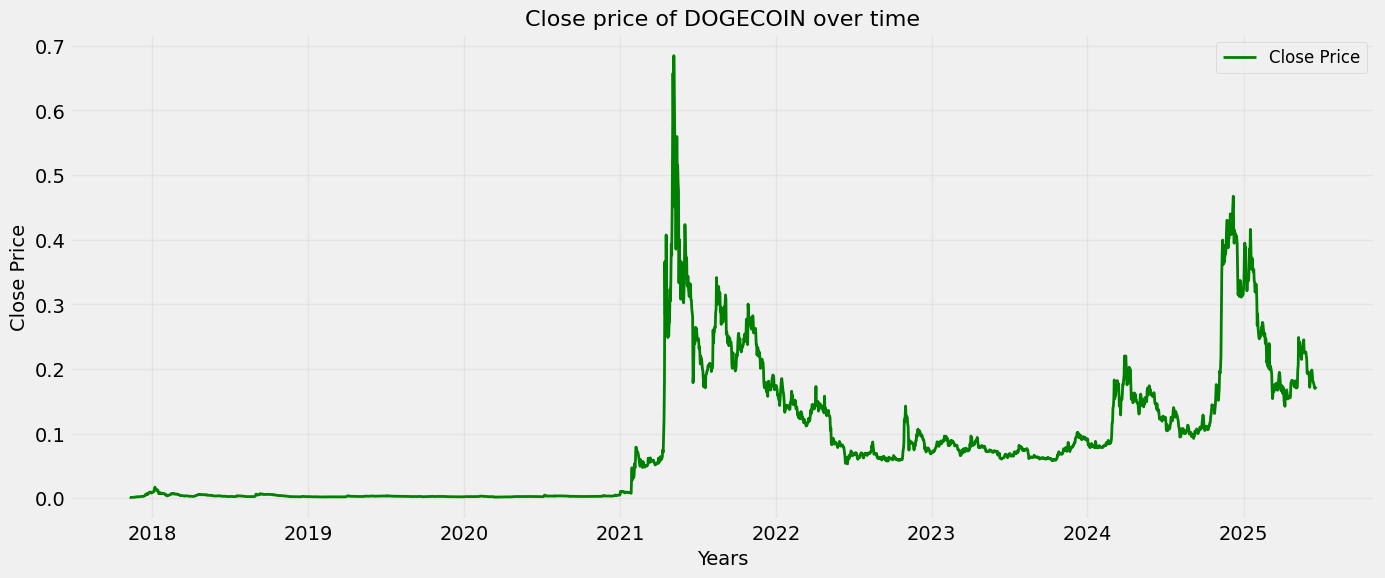

In [44]:
#plotting closing price data with enchacement
plt.figure(figsize=(15,6))
plt.plot(close_data.index,close_data['Close'],label='Close Price',color='green',linewidth=2)
plt.title("Close price of DOGECOIN over time",fontsize=16)
plt.xlabel("Years",fontsize=14)
plt.ylabel('Close Price',fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [45]:
for i in range(2017,2025):
    print(i,list(stock_data.index.year).count(i))

2017 53
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365
2024 366


In [46]:
close_data['MA_365']=close_data['Close'].rolling(window=365).mean()
close_data['MA_50']=close_data['Close'].rolling(window=50).mean()

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_25004\1865463923.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_data['MA_365']=close_data['Close'].rolling(window=365).mean()
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_25004\1865463923.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_data['MA_50']=close_data['Close'].rolling(window=50).mean()


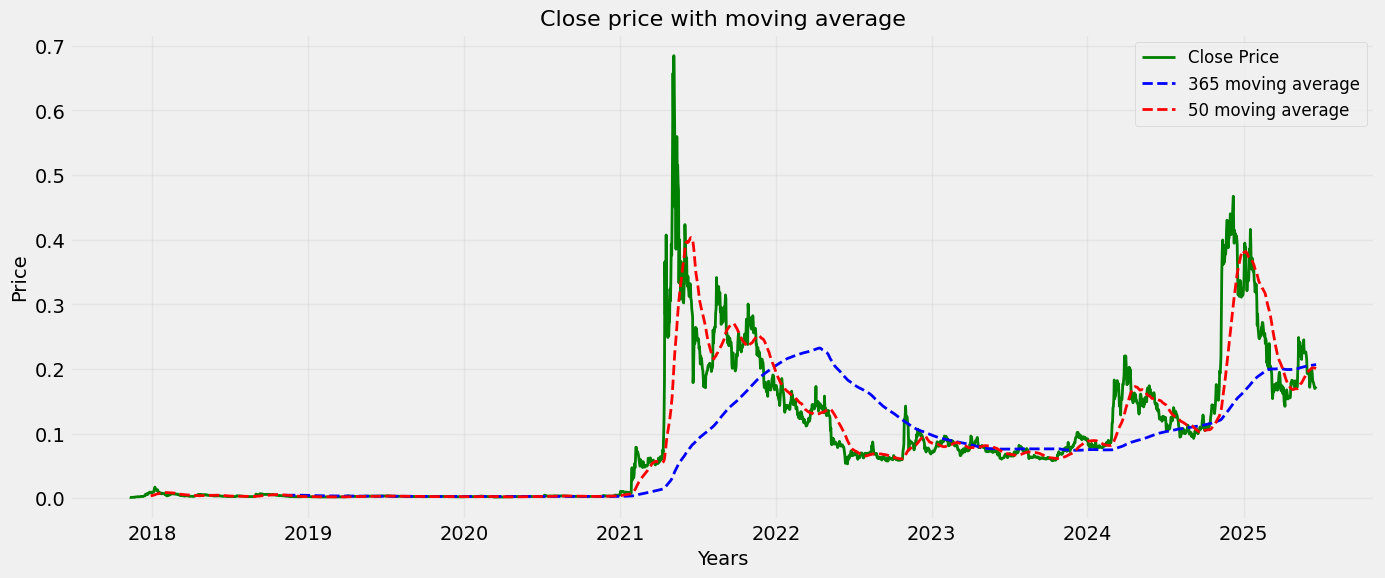

In [47]:
#plotting closing price data with moving average
plt.figure(figsize=(15,6))
plt.plot(close_data.index,close_data['Close'],label='Close Price',color='green',linewidth=2)
plt.plot(close_data.index,close_data['MA_365'],label='365 moving average',color='blue',linewidth=2,linestyle="--")
plt.plot(close_data.index,close_data['MA_50'],label='50 moving average',color='red',linewidth=2,linestyle="--")

plt.title("Close price with moving average",fontsize=16)
plt.xlabel("Years",fontsize=14)
plt.ylabel('Price',fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [48]:
#As this is a time series data we will use LSTM (Long short term memory)
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(close_data[['Close']].dropna())
scaled_data

array([[5.51379910e-04],
       [1.82818322e-04],
       [2.38394995e-04],
       ...,
       [2.48039090e-01],
       [2.48523192e-01],
       [2.46328660e-01]])

In [49]:
from keras.models import Sequential
from keras.layers import Dense,LSTM

In [50]:
#prepare data for LSTM
x_data=[]
y_data=[]
base_days=100
for i in range(base_days,len(scaled_data)):
    x_data.append(scaled_data[i-base_days:i])
    y_data.append(scaled_data[i])
x_data=np.array(x_data)
y_data=np.array(y_data)

    

In [51]:
#split in to train and test dataset
train_size=int(len(x_data)*0.9)
x_train,y_train=x_data[:train_size],y_data[:train_size]
x_test,y_test=x_data[train_size:],y_data[train_size:]

In [52]:
model=Sequential([
    LSTM(128,return_sequences=True,input_shape=(x_train.shape[1],1)),
    LSTM(64,return_sequences=False),
    Dense(25),
    Dense(1)
])
model.compile(optimizer="adam",loss="mean_squared_error")
model.summary()

c:\Users\LAPTOP\Documents\KryptoVal\venv_tf\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.fit(x_train,y_train,batch_size=5,epochs=10)

Epoch 1/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - loss: 0.0028
Epoch 2/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - loss: 8.3177e-04
Epoch 3/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - loss: 6.4624e-04
Epoch 4/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - loss: 4.6298e-04
Epoch 5/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - loss: 5.4876e-04
Epoch 6/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 5.6350e-04
Epoch 7/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - loss: 3.2735e-04
Epoch 8/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - loss: 3.7545e-04
Epoch 9/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - loss: 3.0516e-04
Epoch 10/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 5.0937e-04


In [54]:
predictions=model.predict(x_test)
inv_prediction=scaler.inverse_transform(predictions)
inv_y_test=scaler.inverse_transform(y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


In [55]:
inv_y_test


array([[0.108504  ],
       [0.118176  ],
       [0.123714  ],
       [0.12867101],
       [0.124674  ],
       [0.114428  ],
       [0.107043  ],
       [0.104759  ],
       [0.105099  ],
       [0.109264  ],
       [0.109487  ],
       [0.11148   ],
       [0.108655  ],
       [0.107044  ],
       [0.107939  ],
       [0.10598   ],
       [0.110733  ],
       [0.111416  ],
       [0.111336  ],
       [0.116654  ],
       [0.117527  ],
       [0.125773  ],
       [0.129658  ],
       [0.13721301],
       [0.144527  ],
       [0.142083  ],
       [0.14369   ],
       [0.13950799],
       [0.13849699],
       [0.141987  ],
       [0.13101301],
       [0.137357  ],
       [0.14431199],
       [0.16114999],
       [0.17583901],
       [0.168146  ],
       [0.16137201],
       [0.15918501],
       [0.159316  ],
       [0.151454  ],
       [0.158346  ],
       [0.17017999],
       [0.196658  ],
       [0.193159  ],
       [0.202132  ],
       [0.218761  ],
       [0.27909499],
       [0.349

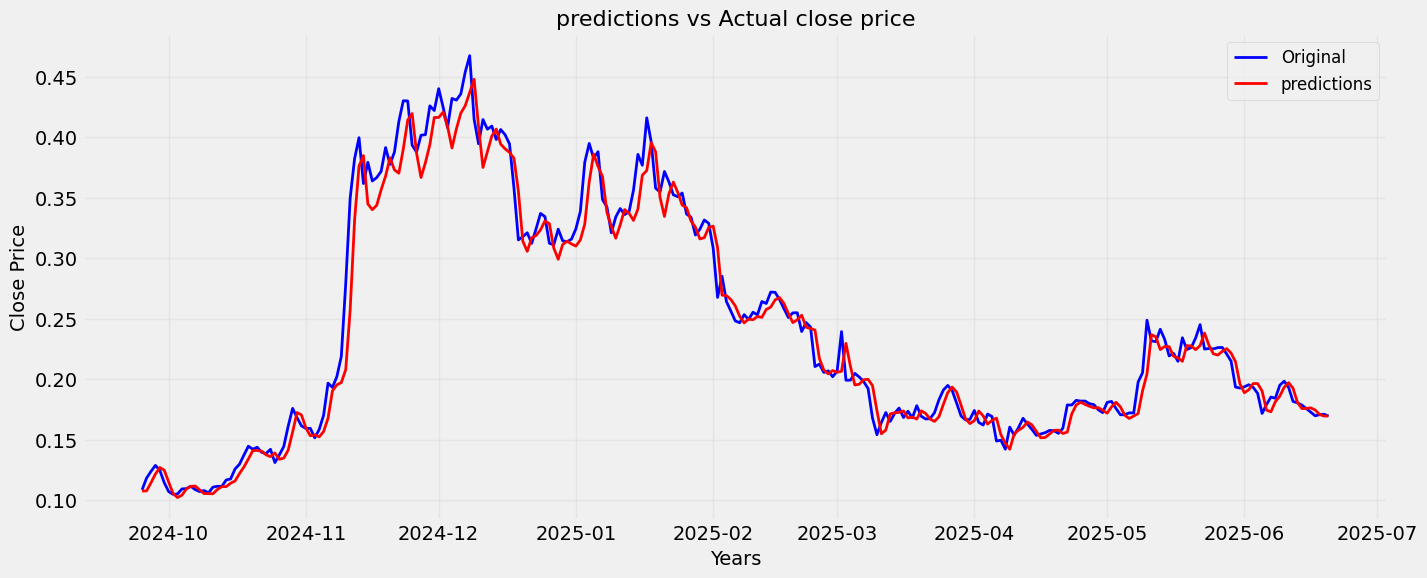

In [56]:
plotting_data=pd.DataFrame(
    {
        'Original':inv_y_test.flatten(),
        'predictions':inv_prediction.flatten(), 
    },index=close_data.index[train_size+base_days:]
)

plt.figure(figsize=(15,6))
plt.plot(plotting_data.index,plotting_data['Original'],label='Original',color='blue',linewidth=2)
plt.plot(plotting_data.index,plotting_data['predictions'],label='predictions',color='red',linewidth=2)

plt.title("predictions vs Actual close price",fontsize=16)
plt.xlabel("Years",fontsize=14)
plt.ylabel('Close Price',fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()


In [57]:
#predicting future days
last_100=scaled_data[-100:].reshape(1,-1,1)
future_predictions=[]
for _ in range(10):
    next_days=model.predict(last_100)
    future_predictions.append(scaler.inverse_transform(next_days))
    last_100=np.append(last_100[:,1:,:],next_days.reshape(1,1,-1),axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [58]:
future_predictions

[array([[0.16897605]], dtype=float32),
 array([[0.1681744]], dtype=float32),
 array([[0.16725342]], dtype=float32),
 array([[0.16628106]], dtype=float32),
 array([[0.1653209]], dtype=float32),
 array([[0.16440745]], dtype=float32),
 array([[0.16354331]], dtype=float32),
 array([[0.16271096]], dtype=float32),
 array([[0.16188858]], dtype=float32),
 array([[0.16106118]], dtype=float32)]

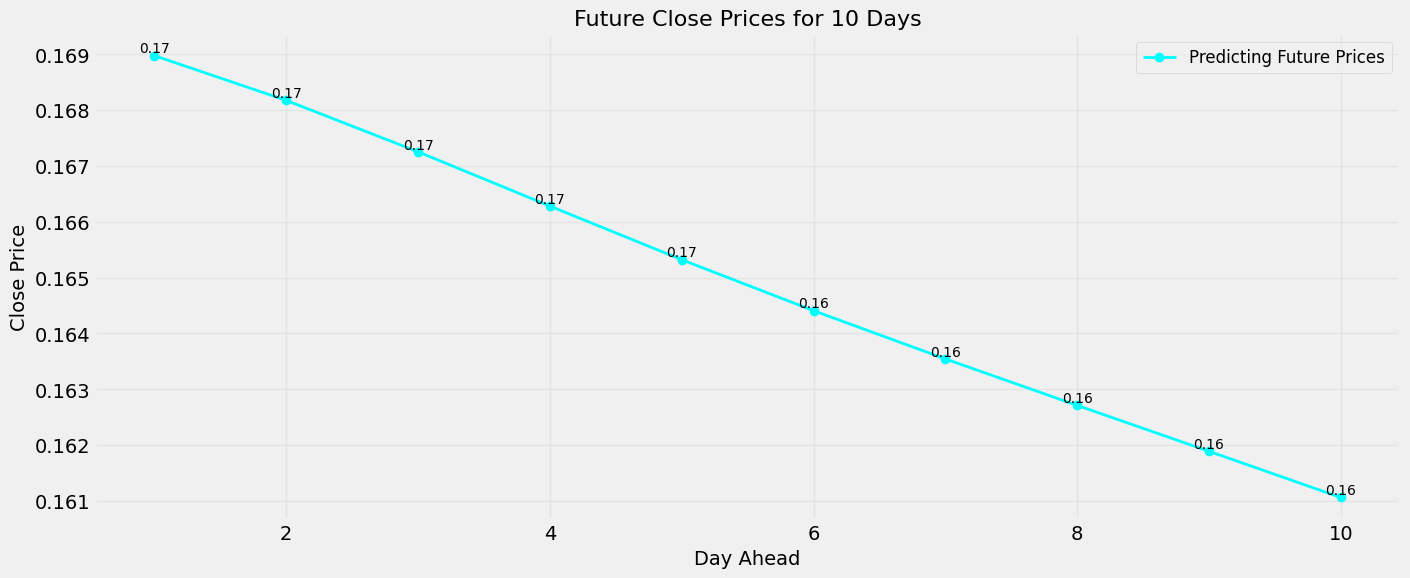

In [59]:
future_predictions=np.array(future_predictions).flatten()
plt.figure(figsize=(15,6))
plt.plot(range(1,11),future_predictions,marker="o",label='Predicting Future Prices',color='cyan',linewidth=2)

for i,val in enumerate(future_predictions):
    plt.text(i+1,val,f'{val:.2f}',fontsize=10,ha='center',va='bottom',color='black')

plt.title("Future Close Prices for 10 Days",fontsize=16)
plt.xlabel("Day Ahead",fontsize=14)
plt.ylabel('Close Price',fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()


In [61]:
model.save("model.keras")